In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: eitharmoutasim
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mssmartypants/rice-type-classification


100%|██████████| 888k/888k [00:00<00:00, 136MB/s]

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
import os
import io
from google.colab import files
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#studyting the data
df = pd.read_csv('/content/riceClassification.csv')
#df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18185 entries, 0 to 18184
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               18185 non-null  int64  
 1   Area             18185 non-null  int64  
 2   MajorAxisLength  18185 non-null  float64
 3   MinorAxisLength  18185 non-null  float64
 4   Eccentricity     18185 non-null  float64
 5   ConvexArea       18185 non-null  int64  
 6   EquivDiameter    18185 non-null  float64
 7   Extent           18185 non-null  float64
 8   Perimeter        18185 non-null  float64
 9   Roundness        18185 non-null  float64
 10  AspectRation     18185 non-null  float64
 11  Class            18185 non-null  int64  
dtypes: float64(8), int64(4)
memory usage: 1.7 MB


The Dataset Class

In [ ]:
class Rice_Dataset(Dataset):
  def __init__(self, data_file_path):
    super().__init__()
    if isinstance(data_file_path, str):
        if os.path.exists(data_file_path):
            # 1. If the file is already uploaded to the sidebar, load it normally
            self.df = pd.read_csv(data_file_path)
        else:
            # 2. If the file isn't found, open an interactive file picker
            print(f"'{data_file_path}' not found in environment. Please upload it manually:")
            uploaded = files.upload()

            # Grab the name of the file that was just uploaded
            file_name = list(uploaded.keys())[0]

            # Read the file directly from memory
            self.df = pd.read_csv(io.BytesIO(uploaded[file_name]))

    self.feature_cols = ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
                             'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter',
                             'Roundness', 'AspectRation']
    scaler = StandardScaler()
    self.df[self.feature_cols] = scaler.fit_transform(self.df[self.feature_cols])

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]

    features = row[self.feature_cols].values.astype(np.float32)
    features_tensor = torch.tensor(features, dtype=torch.float32)

    target = torch.tensor([row['Class']], dtype=torch.float32)

    return features_tensor, target


In [ ]:
# Test our dataset
print("\n" + "="*60)
print("TESTING Rice Data")
print("="*60)
data_file_path = 'SAIR_Courses/4_Applied Deep Learning with PyTorch/lab_assignments/Eithar_Ismail/Classification_hub/Data/riceClassification.csv'
rice_dataset = Rice_Dataset(data_file_path)

print(f"\nDataset length: {len(rice_dataset)}")
print("\nSample items:")
for i in range(3):
    features, target = rice_dataset[i]
    print(f"Sample {i}: Features shape: {features.shape}, Target: {target}")
    print(f"  Features: {features}")


TESTING Rice Data

Dataset length: 18185

Sample items:
Sample 0: Features shape: torch.Size([10]), Target: tensor([1.])
  Features: tensor([-1.7036, -4.8037,  0.4179, -6.3939, -1.6970, -1.8300,  0.3917, -2.6618,
         0.8396, -2.6638])
Sample 1: Features shape: torch.Size([10]), Target: tensor([1.])
  Features: tensor([-2.8385, -6.2208, -0.8356, -6.2096, -2.8035, -3.3981,  0.9231, -4.8573,
         1.8372, -2.6354])
Sample 2: Features shape: torch.Size([10]), Target: tensor([1.])
  Features: tensor([-2.7185, -6.0914, -0.7717, -6.0245, -2.7256, -3.2139,  1.3651, -4.7999,
         2.3836, -2.6060])


In [ ]:
num_cpus = os.cpu_count()
print(f"Setting num_workers to: {num_cpus}")

Setting num_workers to: 2


Dataloaders

In [ ]:
total_size = len(rice_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(rice_dataset, [train_size, val_size])

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=100,
    shuffle=True,        # Crucial to shuffle training data
    num_workers=num_cpus
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=100,
    shuffle=False,       # NEVER shuffle your evaluation data (not necessary)
    num_workers=num_cpus
)

The Model

In [ ]:
class Rice_Classifier(nn.Module):
  def __init__(self):
     super().__init__()
     self.layer1=nn.Linear(10, 64)
     self.layer2=nn.Linear(64, 32)
     self.layer3=nn.Linear(32, 1)
     self.relu=nn.ReLU()

  def forward(self, X):
    z1 = self.layer1(X)
    a1 = self.relu(z1)
    z2 = self.layer2(a1)
    a2 = self.relu(z2)
    z3 = self.layer3(a2)
    return z3

Training Function

In [ ]:
def training_model(model, train_dataset, eval_dataset, epochs=20, lr = 0.01):
  model = model.to(device)
  optimizer = optim.SGD(model.parameters(), lr=lr)
  criterion = nn.BCEWithLogitsLoss()
  training_losses = []
  val_losses = []

  #------------------------------------
  # Model Training
  #------------------------------------
  print("Training Starting")

  for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_feature, batch_target in train_dataset:

      batch_feature = batch_feature.to(device)
      batch_target = batch_target.to(device)

      prediction = model(batch_feature)
      loss = criterion(prediction, batch_target)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_dataset)
    training_losses.append(avg_train_loss)

    #------------------------------------
    # Model Evaluation
    #------------------------------------
    model.eval()
    eval_epoch_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
      for eval_features, eval_target in eval_dataset:
        eval_features = eval_features.to(device)
        eval_target = eval_target.to(device)

        eval_prediction = model(eval_features)
        eval_batch_loss = criterion(eval_prediction, eval_target)

        eval_epoch_loss += eval_batch_loss.item()

        #for accuarcy calculation
        eval_prediction = (torch.sigmoid(eval_prediction) > 0.5).float()

        total += eval_target.size(0)
        correct += (eval_prediction == eval_target).sum().item()

    avg_eval_loss = eval_epoch_loss / len(eval_dataset)
    val_losses.append(avg_eval_loss)
    accuracy = (correct / total) * 100

    print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_eval_loss:.4f} | "
              f"Val Accuracy: {accuracy:.2f}%")

  return training_losses,val_losses, accuracy

Executing the Training Function

In [ ]:
print("\n" + "="*60)
print("Starting A COMPLETE TRAINING LOOP")
print("="*60)

model = Rice_Classifier()

train_loss, eval_loss, final_acc = training_model(
    model,
    train_dataloader,
    val_dataloader,
    epochs=20,
    lr=0.01)

print("Training complete!")


Starting A COMPLETE TRAINING LOOP
Training Starting
Epoch  1/20 | Train Loss: 0.5576 | Val Loss: 0.4058 | Val Accuracy: 98.10%
Epoch  2/20 | Train Loss: 0.2682 | Val Loss: 0.1720 | Val Accuracy: 98.27%
Epoch  3/20 | Train Loss: 0.1227 | Val Loss: 0.0975 | Val Accuracy: 98.30%
Epoch  4/20 | Train Loss: 0.0781 | Val Loss: 0.0721 | Val Accuracy: 98.32%
Epoch  5/20 | Train Loss: 0.0611 | Val Loss: 0.0609 | Val Accuracy: 98.52%
Epoch  6/20 | Train Loss: 0.0532 | Val Loss: 0.0549 | Val Accuracy: 98.54%
Epoch  7/20 | Train Loss: 0.0486 | Val Loss: 0.0513 | Val Accuracy: 98.60%
Epoch  8/20 | Train Loss: 0.0456 | Val Loss: 0.0489 | Val Accuracy: 98.65%
Epoch  9/20 | Train Loss: 0.0436 | Val Loss: 0.0471 | Val Accuracy: 98.65%
Epoch 10/20 | Train Loss: 0.0420 | Val Loss: 0.0458 | Val Accuracy: 98.63%
Epoch 11/20 | Train Loss: 0.0410 | Val Loss: 0.0448 | Val Accuracy: 98.63%
Epoch 12/20 | Train Loss: 0.0401 | Val Loss: 0.0440 | Val Accuracy: 98.65%
Epoch 13/20 | Train Loss: 0.0396 | Val Loss: 0.

Results Plotting

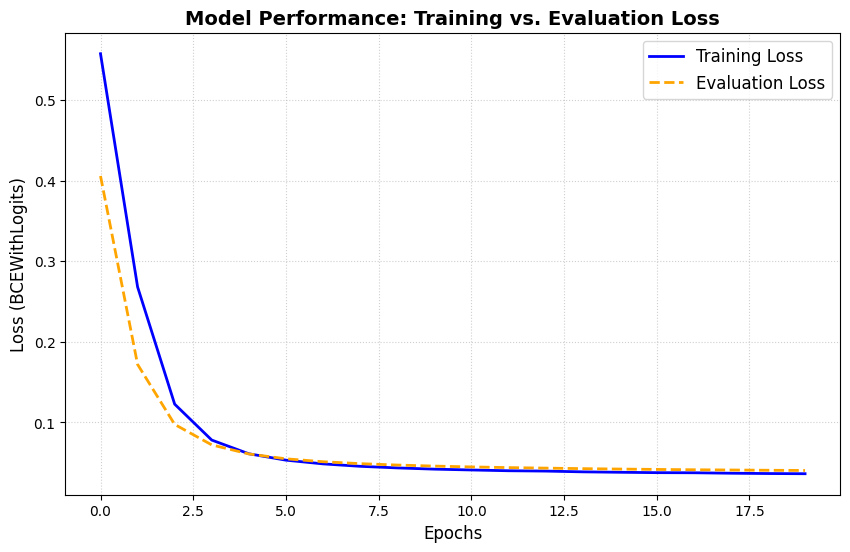

In [ ]:
# Set the figure size for better readability
plt.figure(figsize=(10, 6))

# Plot both lines
plt.plot(train_loss, label="Training Loss", color="blue", linewidth=2)
plt.plot(eval_loss, label="Evaluation Loss", color="orange", linewidth=2, linestyle="--")

# Add titles and labels
plt.title("Model Performance: Training vs. Evaluation Loss", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss (BCEWithLogits)", fontsize=12)

# Add a grid and a legend so you know which line is which
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=12)

# Display the plot
plt.show()

Saving the model for inference

In [ ]:
MODEL_PATH = "rice_classifier.pth"

# Save the weights (state_dict)
torch.save(model.state_dict(), MODEL_PATH)

Live Inference Demo

In [ ]:
"""
Rice Type Classifier — Live Inference Demo
==========================================
Run:  python rice_demo.py
Then open the local URL printed in the terminal.

The demo reconstructs the trained model architecture, lets you either:
  1. Load a saved .pth checkpoint  (recommended)
  2. Re-train quickly on the CSV   (fallback)

Then enter raw rice measurements and get an instant prediction.
"""

import os
import io
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import gradio as gr

# ──────────────────────────────────────────────
# 1.  Model definition  (must match training)
# ──────────────────────────────────────────────
FEATURE_COLS = [
    "Area", "MajorAxisLength", "MinorAxisLength", "Eccentricity",
    "ConvexArea", "EquivDiameter", "Extent", "Perimeter",
    "Roundness", "AspectRation",
]

FEATURE_DESCRIPTIONS = {
    "Area":            ("Grain area (px²)",          0,    100000),
    "MajorAxisLength": ("Major axis length (px)",     0,    800),
    "MinorAxisLength": ("Minor axis length (px)",     0,    400),
    "Eccentricity":    ("Eccentricity  [0–1]",        0.0,  1.0),
    "ConvexArea":      ("Convex hull area (px²)",     0,    110000),
    "EquivDiameter":   ("Equivalent diameter (px)",   0,    400),
    "Extent":          ("Extent  [0–1]",              0.0,  1.0),
    "Perimeter":       ("Perimeter (px)",             0,    2500),
    "Roundness":       ("Roundness  [0–1]",           0.0,  1.0),
    "AspectRation":    ("Aspect ratio",               1.0,  10.0),
}

# Typical Jasmine sample (class 1) — used as slider defaults
DEFAULT_VALUES = {
    "Area":            14200,
    "MajorAxisLength": 210.0,
    "MinorAxisLength": 90.0,
    "Eccentricity":    0.90,
    "ConvexArea":      14800,
    "EquivDiameter":   134.0,
    "Extent":          0.68,
    "Perimeter":       590.0,
    "Roundness":       0.51,
    "AspectRation":    2.34,
}

CLASS_NAMES = {0: "Gonen (Class 0)", 1: "Jasmine (Class 1)"}
CLASS_COLORS = {0: "#3B82F6", 1: "#10B981"}   # blue / green


class RiceClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(10, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 1)
        self.relu   = nn.ReLU()

    def forward(self, x):
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))


# ──────────────────────────────────────────────
# 2.  Global state  (model + scaler)
# ──────────────────────────────────────────────
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model   = RiceClassifier().to(device)
scaler  = StandardScaler()
_ready  = False          # True once weights + scaler are loaded


def _fit_scaler_from_csv(csv_path: str) -> bool:
    """Fit the StandardScaler from the training CSV."""
    global scaler
    try:
        df = pd.read_csv(csv_path)
        scaler.fit(df[FEATURE_COLS].values)
        return True
    except Exception as e:
        print(f"[scaler] Could not fit from CSV: {e}")
        return False


def _train_quick(csv_path: str, epochs: int = 15) -> str:
    """Quick re-train on the CSV so the demo works without a saved checkpoint."""
    global model, scaler, _ready
    from torch.utils.data import DataLoader, TensorDataset, random_split
    import torch.optim as optim

    df = pd.read_csv(csv_path)
    X  = df[FEATURE_COLS].values.astype(np.float32)
    y  = df["Class"].values.astype(np.float32).reshape(-1, 1)

    scaler.fit(X)
    X_scaled = scaler.transform(X)

    dataset = TensorDataset(torch.tensor(X_scaled), torch.tensor(y))
    n_train  = int(0.8 * len(dataset))
    train_ds, _ = random_split(dataset, [n_train, len(dataset) - n_train])
    loader   = DataLoader(train_ds, batch_size=128, shuffle=True)

    optimizer = optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.BCEWithLogitsLoss()
    model.train()
    for ep in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()
        print(f"  quick-train epoch {ep+1}/{epochs}")

    _ready = True
    return f"✅ Quick-trained for {epochs} epochs on {len(dataset):,} samples."


# ──────────────────────────────────────────────
# 3.  Load handlers
# ──────────────────────────────────────────────
def load_checkpoint(pth_file, csv_file):
    """Load weights from .pth and fit scaler from CSV."""
    global model, _ready
    msgs = []

    # --- weights ---
    if pth_file is not None:
        try:
            state = torch.load(pth_file.name, map_location=device)
            # handle raw state_dict or {'model_state_dict': ...} wrappers
            if isinstance(state, dict) and "model_state_dict" in state:
                state = state["model_state_dict"]
            model.load_state_dict(state)
            model.eval()
            msgs.append("✅ Model weights loaded.")
        except Exception as e:
            msgs.append(f"❌ Could not load weights: {e}")
            return "\n".join(msgs)
    else:
        msgs.append("⚠️  No .pth file — weights are random (upload or re-train).")

    # --- scaler ---
    if csv_file is not None:
        ok = _fit_scaler_from_csv(csv_file.name)
        msgs.append("✅ Scaler fitted from CSV." if ok else "❌ Scaler fitting failed.")
        _ready = ok
    else:
        msgs.append("⚠️  No CSV — scaler not fitted. Upload CSV or use Re-train tab.")

    return "\n".join(msgs)


def retrain(csv_file, epochs):
    """Re-train the model from scratch on the uploaded CSV."""
    if csv_file is None:
        return "❌ Please upload the CSV first."
    model.__init__()          # reset weights
    for p in model.parameters():
        p.data = torch.zeros_like(p.data)
    model.__init__()
    return _train_quick(csv_file.name, int(epochs))


# ──────────────────────────────────────────────
# 4.  Inference
# ──────────────────────────────────────────────
def predict(*values):
    if not _ready:
        return (
            "⚠️  Model not ready — go to **Setup** tab first.",
            "",
            None,
        )

    raw = np.array(values, dtype=np.float32).reshape(1, -1)
    scaled = scaler.transform(raw).astype(np.float32)
    tensor = torch.tensor(scaled).to(device)

    model.eval()
    with torch.no_grad():
        logit = model(tensor).item()

    prob_jasmine = torch.sigmoid(torch.tensor(logit)).item()
    prob_gonen   = 1.0 - prob_jasmine
    pred_class   = 1 if prob_jasmine > 0.5 else 0
    label        = CLASS_NAMES[pred_class]
    confidence   = max(prob_jasmine, prob_gonen) * 100

    # ── bar chart data for gr.BarPlot ──
    chart_df = pd.DataFrame({
        "Rice Type":    ["Gonen", "Jasmine"],
        "Probability":  [round(prob_gonen, 4), round(prob_jasmine, 4)],
    })

    result_md = (
        f"## 🌾 Predicted: **{label}**\n\n"
        f"Confidence: **{confidence:.1f}%**\n\n"
        f"| Rice Type | Probability |\n"
        f"|-----------|-------------|\n"
        f"| Gonen     | {prob_gonen*100:.1f}% |\n"
        f"| Jasmine   | {prob_jasmine*100:.1f}% |"
    )

    status = f"Logit: {logit:.4f}  |  σ(logit) = {prob_jasmine:.4f}"
    return result_md, status, chart_df


# ──────────────────────────────────────────────
# 5.  Gradio UI
# ──────────────────────────────────────────────
with gr.Blocks(title="🌾 Rice Type Classifier", theme=gr.themes.Soft()) as demo:

    gr.Markdown(
        """
        # 🌾 Rice Type Classifier — Live Inference Demo
        Binary classifier: **Gonen** (class 0) vs **Jasmine** (class 1)

        **Step 1 →** Go to the *Setup* tab and load your model.
        **Step 2 →** Come back to *Predict* and adjust the sliders.
        """
    )

    # ── Tabs ──
    with gr.Tabs():

        # ═══════════════════════════════
        # Tab 1 — Predict
        # ═══════════════════════════════
        with gr.Tab("🔍 Predict"):
            gr.Markdown("Adjust the raw measurements below and click **Predict**.")

            sliders = []
            with gr.Row():
                with gr.Column():
                    for feat in FEATURE_COLS[:5]:
                        desc, lo, hi = FEATURE_DESCRIPTIONS[feat]
                        sl = gr.Slider(
                            minimum=lo, maximum=hi,
                            value=DEFAULT_VALUES[feat],
                            step=(hi - lo) / 1000,
                            label=f"{feat}  —  {desc}",
                        )
                        sliders.append(sl)
                with gr.Column():
                    for feat in FEATURE_COLS[5:]:
                        desc, lo, hi = FEATURE_DESCRIPTIONS[feat]
                        sl = gr.Slider(
                            minimum=lo, maximum=hi,
                            value=DEFAULT_VALUES[feat],
                            step=(hi - lo) / 1000,
                            label=f"{feat}  —  {desc}",
                        )
                        sliders.append(sl)

            predict_btn = gr.Button("🔮 Predict", variant="primary", size="lg")

            with gr.Row():
                with gr.Column(scale=2):
                    result_md  = gr.Markdown("*Results will appear here.*")
                    status_txt = gr.Textbox(label="Debug info", interactive=False)
                with gr.Column(scale=1):
                    bar_plot = gr.BarPlot(
                        x="Rice Type",
                        y="Probability",
                        title="Class Probabilities",
                        y_lim=[0, 1],
                        color="Rice Type",
                        color_map={"Gonen": "#3B82F6", "Jasmine": "#10B981"},
                        height=250,
                    )

            predict_btn.click(
                fn=predict,
                inputs=sliders,
                outputs=[result_md, status_txt, bar_plot],
            )

        # ═══════════════════════════════
        # Tab 2 — Setup
        # ═══════════════════════════════
        with gr.Tab("⚙️ Setup"):
            gr.Markdown(
                """
                ### Option A — Load a saved checkpoint
                Upload your `.pth` file **and** the original `riceClassification.csv`
                (needed to refit the StandardScaler with the correct statistics).
                """
            )
            with gr.Row():
                pth_upload = gr.File(label="Model weights (.pth)", file_types=[".pth"])
                csv_upload = gr.File(label="Training CSV (.csv)",  file_types=[".csv"])
            load_btn    = gr.Button("Load", variant="primary")
            load_status = gr.Textbox(label="Status", interactive=False)

            load_btn.click(
                fn=load_checkpoint,
                inputs=[pth_upload, csv_upload],
                outputs=load_status,
            )

            gr.Markdown("---")
            gr.Markdown(
                """
                ### Option B — Quick re-train in the browser
                No saved weights? Upload only the CSV and re-train for a few epochs right here.
                """
            )
            with gr.Row():
                csv_retrain = gr.File(label="Training CSV (.csv)", file_types=[".csv"])
                epochs_sl   = gr.Slider(5, 50, value=15, step=5, label="Epochs")
            retrain_btn    = gr.Button("Re-train", variant="secondary")
            retrain_status = gr.Textbox(label="Status", interactive=False)

            retrain_btn.click(
                fn=retrain,
                inputs=[csv_retrain, epochs_sl],
                outputs=retrain_status,
            )

        # ═══════════════════════════════
        # Tab 3 — About the features
        # ═══════════════════════════════
        with gr.Tab("📖 Feature Reference"):
            gr.Markdown(
                """
                | Feature | Description | Typical range |
                |---------|-------------|---------------|
                | **Area** | Number of pixels within the grain boundary | 0 – 100 000 |
                | **MajorAxisLength** | Length of the longest axis through the grain | 0 – 800 px |
                | **MinorAxisLength** | Length of the shortest axis | 0 – 400 px |
                | **Eccentricity** | How elongated the grain is (0 = circle, 1 = line) | 0 – 1 |
                | **ConvexArea** | Area of the smallest convex polygon enclosing the grain | 0 – 110 000 |
                | **EquivDiameter** | Diameter of a circle with the same area | 0 – 400 px |
                | **Extent** | Ratio of grain area to its bounding rectangle | 0 – 1 |
                | **Perimeter** | Length of the grain boundary | 0 – 2 500 px |
                | **Roundness** | 4π × Area / Perimeter² (1 = perfect circle) | 0 – 1 |
                | **AspectRation** | MajorAxis / MinorAxis | 1 – 10 |

                **Classes**
                - `0` → **Gonen** — shorter, rounder grains
                - `1` → **Jasmine** — longer, more elongated grains
                """
            )

    gr.Markdown(
        "_Model: 3-layer MLP (10 → 64 → 32 → 1) · Loss: BCEWithLogitsLoss · "
        "Optimizer: SGD · Normalisation: StandardScaler_"
    )

if __name__ == "__main__":
    demo.launch(share=False)

/tmp/ipykernel_1077/85689145.py:222: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="🌾 Rice Type Classifier", theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>